In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_groq import ChatGroq
from pydantic import BaseModel,Field
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model = "llama-3.1-8b-instant"
)

In [21]:
# Structure of find_sentiment node
class SentimentSchema(BaseModel):
    sentiment : Literal["positive","negative"]= Field(description='Sentiment of the review')

In [29]:
# Structure of run_diagnose node
class diagnoseSchema(BaseModel):
    issuetype: Literal["UX","Performance","Bug","Support","Other"] = Field(description='The category of issue mentiuoned by user')
    tone: Literal['angry','frustrated','calm','disappointed'] = Field(description='The emotional tone expressed by the user')
    urgency: Literal['low','medium','high'] = Field(description='How critical or urgent the issue supposed to be')

In [30]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(diagnoseSchema)

In [7]:
# Checking the structured model 
prompt = " what is the sentiment of the review - Software is too bad"
structured_model.invoke(prompt).sentiment

'negative'

In [8]:
# Createing state 
class reviewHandlingState(TypedDict):
    review:str
    sentiment: Literal['positive','negative']
    diagnosis: dict
    response: str

In [24]:
def find_sentiment(state:reviewHandlingState):
    review = state['review']

    prompt = f" what is the sentiment of the review - {review}"
    sentiment=structured_model.invoke(prompt).sentiment
    
    return {'sentiment':sentiment}

In [23]:
# Creating condition 
def check_condition(state:reviewHandlingState)->Literal['run_diagnose','positive_response']:
    sentiment = state['sentiment']

    if sentiment == 'positive':
        return "positive_response"
    else:
        return "run_diagnose"

In [11]:
def positive_response(state:reviewHandlingState):
    review = state['review']

    prompt = f" write a warm thankyou message on this review - {review} \n also ask user to leave feedback on our website."
    response=model.invoke(prompt).content
    
    return {'response':response}

In [31]:
def run_diagnose(state:reviewHandlingState):
    review = state['review']

    prompt = f" Diagnose this negative review - {review}\n Return issue_type, tone and urgency"
    diagnosis=structured_model2.invoke(prompt)
    
    return {'diagnosis':diagnosis.model_dump()} # model_dump() --> json object ko dictionary mein convert kr de ga

In [18]:
def negative_response(state:reviewHandlingState):
    diagnosis = state['diagnosis']

    prompt = f" You are a support assistant. The user had a  - {diagnosis['issuetype']} issue, sounded {diagnosis['tone']} and marked urgency as {diagnosis['urgency']}. Write an empathetic resolution message."
    response=model.invoke(prompt).content
    
    return {'response':response}

In [32]:
# Create Graph 
graph = StateGraph(reviewHandlingState)

# Add nodes to graph
graph.add_node('find_sentiment',find_sentiment)
graph.add_node('run_diagnose',run_diagnose)
graph.add_node('positive_response',positive_response)
graph.add_node('negative_response',negative_response)

# Add edges to graph 
graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_condition)
graph.add_edge('run_diagnose','negative_response')
graph.add_edge('negative_response',END)
graph.add_edge('positive_response',END)

# Compile Graph 
workflow = graph.compile()

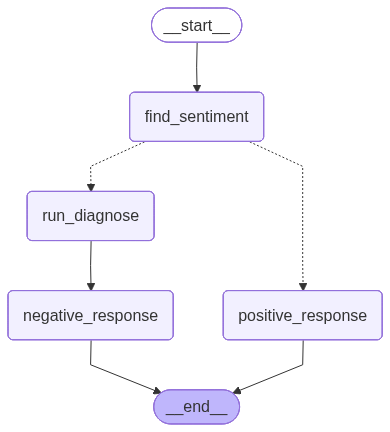

In [15]:
# Visualize the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [33]:
# Execute teh graph 
initial_state = {
    'review': 'The overall experience with the software has been quite disappointing. The application crashes frequently and its performance is very slow, which makes it difficult to complete tasks efficiently. The user interface is confusing, and even basic features are not intuitive to use. Despite reporting multiple bugs, there has been no proper fix so far. I hope the team takes these issues seriously and works on improving the product soon.'}
workflow.invoke(initial_state)

{'review': 'The overall experience with the software has been quite disappointing. The application crashes frequently and its performance is very slow, which makes it difficult to complete tasks efficiently. The user interface is confusing, and even basic features are not intuitive to use. Despite reporting multiple bugs, there has been no proper fix so far. I hope the team takes these issues seriously and works on improving the product soon.',
 'sentiment': 'negative',
 'diagnosis': {'issuetype': 'Bug', 'tone': 'disappointed', 'urgency': 'high'},
 'response': "Subject: Re: Urgent Bug Issue - Resolved and Apologies\n\nDear [User],\n\nI hope this message finds you well, despite the frustration caused by the recent bug issue. I can only imagine how disappointing it must be to encounter such problems, especially with high urgency. Please accept my sincerest apologies for the inconvenience this has caused.\n\nI'm pleased to inform you that our team has investigated the issue thoroughly and

In [26]:
# Execute teh graph 
initial_state = {
    'review': "Thank you so much for this opportunity. I really appreciate it and I’m happy to move forward. Looking forward to the next steps!"
}
workflow.invoke(initial_state)

{'review': 'Thank you so much for this opportunity. I really appreciate it and I’m happy to move forward. Looking forward to the next steps!',
 'sentiment': 'positive',
 'response': 'Here\'s a revised message:\n\n"Thank you so much for this opportunity. I really appreciate it and I\'m happy to move forward. Looking forward to the next steps!\n\nIf you have a moment, we\'d love to hear about your experience with our company. Your feedback is invaluable to us and can be left on our website. Your input will help us continue to improve and provide the best possible service. Thank you again for your time and consideration!"\n\nThis message still conveys gratitude and appreciation, but also politely asks the user to provide feedback on the company\'s website.'}